In [4]:
# Import relevant libraries and modules.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# This is the classifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance 
from xgboost import plot_importance


In [6]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

### YOUR CODE HERE ###

airline_data = pd.read_csv('Invistico_Airline.csv', on_bad_lines='skip')

In [7]:
airline_data.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


In [8]:
airline_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

In [22]:
airline_data.dtypes

satisfaction                             str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
dtype: obj

In [19]:
airline_data['satisfaction'].unique()

<StringArray>
['satisfied', 'dissatisfied']
Length: 2, dtype: str

In [25]:
air_data_dummies = pd.get_dummies(airline_data, columns=["Customer Type", "Type of Travel", "Class"])
mapping = {"satisfied": 1, "dissatisfied": 0}
air_data_dummies['satisfaction'] = airline_data['satisfaction'].map(mapping)                                                         

In [26]:
air_data_dummies.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  int64  
 1   Age                                129880 non-null  int64  
 2   Flight Distance                    129880 non-null  int64  
 3   Seat comfort                       129880 non-null  int64  
 4   Departure/Arrival time convenient  129880 non-null  int64  
 5   Food and drink                     129880 non-null  int64  
 6   Gate location                      129880 non-null  int64  
 7   Inflight wifi service              129880 non-null  int64  
 8   Inflight entertainment             129880 non-null  int64  
 9   Online support                     129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  On-board service                   129880 non-null

In [27]:
y = air_data_dummies['satisfaction']
X = air_data_dummies.copy()
X = X.drop('satisfaction', axis=1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [28]:
# Define xgb to be your XGBClassifier.
xgb = XGBClassifier(objective='binary:logistic', random_state=0) 

In [30]:
# Define parameters for tuning as `cv_params`.
cv_params = {'max_depth': [4], 
             'min_child_weight': [3],
             'learning_rate': [0.1],
             'n_estimators': [50,100,150],
             'subsample': [0.7],
             'colsample_bytree': [0.7]
             }    


In [31]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

In [32]:
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='f1')

In [33]:
xgb_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7], 'learning_rate': [0.1], 'max_depth': [4], 'min_child_weight': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [34]:
# Define a path to the folder where you want to save the model
path = 'C:/Users/Admin/Documents/jupyter notebook/Coursera/coursera'

In [36]:
# Pickle the model
# This module lets us save our models once we fit them.
import pickle
with open(path + 'xgb_cv_model.pickle', 'wb') as to_write:
    pickle.dump(xgb_cv, to_write) 

In [37]:
# Open pickled model
with open(path+'xgb_cv_model.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)

In [38]:
# Brug den trænede model (xgb_cv) til at lave forudsigelser på test-sættet
y_pred = xgb_cv.predict(X_test)

# Valgfrit: Se de første 10 forudsigelser for at tjekke resultatet
print(y_pred[:10])

[1 1 1 1 0 0 1 0 0 0]


In [39]:
# Importér de nødvendige metrics fra scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Beregn hver metric ved at sammenligne y_test (facit) med y_pred (modellens gæt)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print resultaterne med 4 decimaler
print(f"Accuracy score:  {accuracy:.4f}")
print(f"Precision score: {precision:.4f}")
print(f"Recall score:    {recall:.4f}")
print(f"F1 score:       {f1:.4f}")

Accuracy score:  0.9395
Precision score: 0.9515
Recall score:    0.9373
F1 score:       0.9443


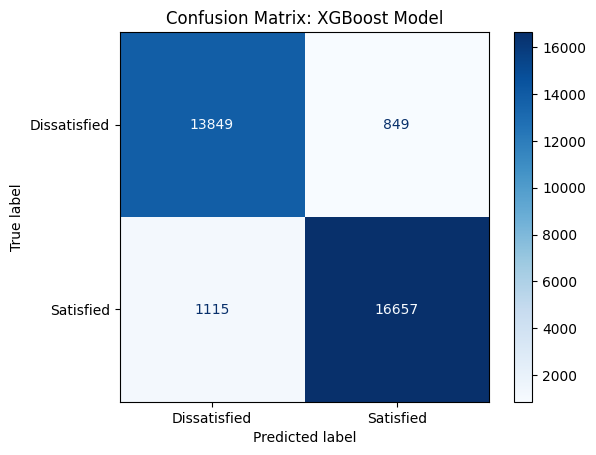

In [40]:
# Construct and display your confusion matrix.

# Construct the confusion matrix for your predicted and test values.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Beregn selve Confusion Matrix
# Vi bruger labels=[0, 1] da vi har mappet dem til tal
cm = confusion_matrix(y_test, y_pred, labels=xgb_cv.classes_)

# Create the display for your confusion matrix.

# 2. Opsæt den visuelle visning
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dissatisfied", "Satisfied"])


# Plot the visual in-line.
# 3. Plot figuren
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: XGBoost Model')
plt.show()

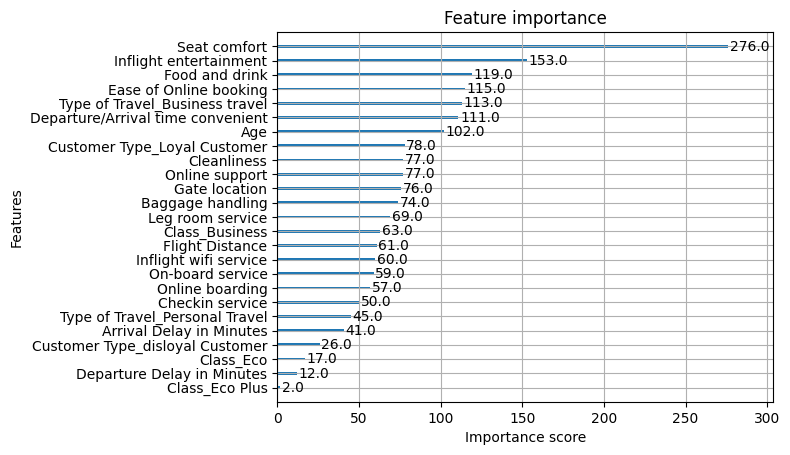

In [41]:
# 1. Importér plot_importance fra xgboost
from xgboost import plot_importance
import matplotlib.pyplot as plt

# 2. Plot feature importance baseret på den bedste model fra din GridSearch
# Vi bruger 'xgb_cv.best_estimator_', da det er den færdigtrænede vinder-model
plot_importance(xgb_cv.best_estimator_)

# 3. Vis plottet
plt.rcParams["figure.figsize"] = (10, 8) # Gør figuren lidt større og læselig
plt.show()